In [1]:
%load_ext autoreload
%autoreload 2

import os,sys
parent_dir = os.path.abspath('..')
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)
import util as yu
from util import *
import util_Nsgm as yu2

yu.setpath('analysis_1t1laplce')

ens='b'
tfs=[8,10,12,14,16,18,20]

yunit_mul=yu.ens2amul_iso[ens]*yu.ens2aInv[ens]

In [2]:
[c2ptM,tf2c3ptM,c2ptCorrDic_NJN]=yu.load_pkl_reg('data',pathlabel='processData')
tf2c3ptM={tf:np.real(tf2c3ptM[tf]) for tf in tf2c3ptM.keys()}

In [75]:
# 1-1 solution

dt=1
def dE2factor(dE):
    c0=1
    c2=(np.exp(-dE*dt)-2+np.exp(dE*dt))/(dt**2)
    c4=(np.exp(-2*dE*dt)-4*np.exp(-dE*dt)+6-4*np.exp(dE*dt)+np.exp(2*dE*dt))/(dt**4)
    c=c4/c2
    return c
def factor2dE(c):
    return yu.fsolve2(lambda dE: dE2factor(dE) - c, 0.1)
    
tf2dE={}
for tf in tfs:
    c3=tf2c3ptM[tf][:,:,0,0]
    c2=c2ptCorrDic_NJN[tf]
    
    c3pp=(np.roll(c3,-dt,axis=-1)-2*c3+np.roll(c3,dt,axis=-1))/(dt**2)
    c3pppp=(np.roll(c3,-2*dt,axis=-1)-4*np.roll(c3,-dt,axis=-1)+6*c3-4*np.roll(c3,dt,axis=-1)+np.roll(c3,2*dt,axis=-1))/(dt**4)

    t=c3pppp/c3pp
    dE=np.sqrt(t)
    # dE=np.array([[factor2dE(ele) for ele in row] for row in t])
    tf2dE[tf]=dE

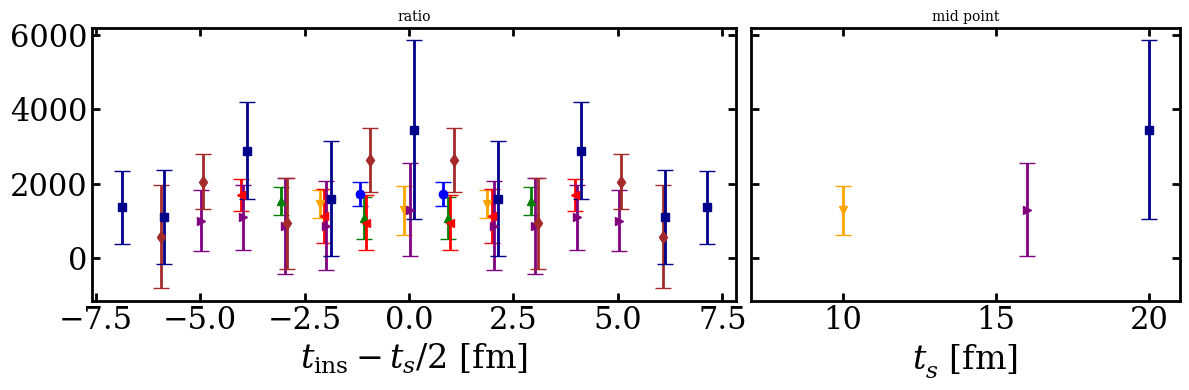

In [76]:
fig,axs=yu.makePlot_3pt_rainbow(tf2dE,tcmin=dt*2+1,yunit=yu.ens2aInv[ens])
# axs[0,0].set_ylim([0,3000])
yu.finalizePlot()